# Tool Classification and Location using YOLOv8

## Project Description
This project implements a real-time object detection system for the classification and location of industrial tools. It uses the **YOLO (You Only Look Once)** architecture, optimized to offer a balance between accuracy and inference speed.

The model is trained to identify 6 specific classes:
- Cutter
- Tongs
- Screws_box
- Screwdriver
- Drill_bit
- Allen_keys

## Objectives
1. Adapt the "SingleDetectionTool" dataset to the format required by YOLO.
2. Divide the dataset into training, validation, and test sets.
3. Train and validate the YOLOv8 model.
4. Compare the performance obtained with previous architectures such as MobileNet and Vision Transformers (ViT).

## 1. Environment Setup

In this section, the necessary libraries are loaded for image processing (`OpenCV`, `Matplotlib`), data manipulation (`Pandas`, `NumPy`), and file management in the Google Colab environment.


In [1]:
# Import necessary libraries

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
import random
from matplotlib.patches import Rectangle
from matplotlib import pyplot
from lxml import etree
from sklearn.model_selection import train_test_split #function to split a dataset
import shutil #library with function to copy files between folders
from sklearn.preprocessing import LabelBinarizer

# Enable Matplotlib backend for displaying static images
%matplotlib inline

## 2. Dataset Preparation and Organization

To ensure robust training, we proceed to:

1. **Unzip** the original laboratory files.
2. **Structure** the folders following the YOLO standard (`train`, `val`, `test`).
3. **Split** the 600 images (100 per class) randomly to avoid bias in the learning process.

In [2]:

# NOTE: This notebook was originally developed in Google Colab.
# The Google Drive mount cell has been removed for local execution.
# Make sure the dataset zip file is placed at the path defined below.

In [2]:
import os

# LOCAL PATHS — adjust these if your folder structure differs.
# Expected dataset zip: data/Label_studio.zip

BASE_DIR  = os.path.dirname(os.path.abspath('__file__'))  # notebook directory
PATH      = os.path.join(BASE_DIR, 'data', '')            # working data folder
DATA_ZIP  = os.path.join(BASE_DIR, 'data', 'Label_studio.zip')  # dataset zip
RUNS_PATH = os.path.join(BASE_DIR, 'runs', 'detect', '')  # YOLO output folder

In [8]:
import zipfile

# Unzip dataset locally
os.makedirs(PATH, exist_ok=True)
with zipfile.ZipFile(DATA_ZIP, 'r') as zip_ref:
    zip_ref.extractall(PATH)
print('Dataset extracted to:', PATH)

Dataset extracted to: c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\


In [9]:
# Inspect Data, there are 100 images for each of the 6 classes, for a total of 600.

images_names = os.listdir(PATH+'Label_studio/images')
print('Total images: ', len(images_names))
xml_names = os.listdir(PATH+'Label_studio/labels')
print('Total annotations: ', len(xml_names))

Total images:  600
Total annotations:  600


### Split the data into three folders: train, validation, and test

In [10]:
def get_class_from_YOLO(path):

    with open(path, 'r') as file:
        return file.read()[0]

get_class_from_YOLO(os.path.join(PATH, 'Label_studio', 'labels', '00451535-drill_bit28.txt'))

'2'

In [11]:
# Create folders to Data and Models
try:
    os.makedirs(PATH+'Data', exist_ok=True)
    os.makedirs(PATH+'Data/Train', exist_ok=True)
    os.makedirs(PATH+'Data/Train/images', exist_ok=True)
    os.makedirs(PATH+'Data/Train/labels', exist_ok=True)
    os.makedirs(PATH+'Data/Valid', exist_ok=True)
    os.makedirs(PATH+'Data/Valid/images', exist_ok=True)
    os.makedirs(PATH+'Data/Valid/labels', exist_ok=True)
    os.makedirs(PATH+'Data/Test', exist_ok=True)
    os.makedirs(PATH+'Data/Test/images', exist_ok=True)
    os.makedirs(PATH+'Data/Test/labels', exist_ok=True)
except:
    print('Error creating folders')

# Define path to folders
path_images = PATH+'Label_studio/images'
path_xml = PATH+'Label_studio/labels'
path_train = PATH+'Data/Train'
path_valid = PATH+'Data/Valid'
path_test = PATH+'Data/Test'

# Get the class of each image
elements = []

for item in xml_names:
    name = item
    label = get_class_from_YOLO(os.path.join(path_xml,item))
    elements.append([name,label])

# Convert elements inta a pandas dataframe, and get class labels
df = pd.DataFrame(elements, columns=['name','label'])
labels = df['label'].unique()

# Create class dictionary
Class_dict = dict(zip(labels, range(1,len(labels) + 1)))

# Obtain a dataset for each class
list_df = []
for label in labels:
    list_df.append('df_'+label)

for i in range(len(labels)):
    list_df[i] = df[df['label'] == labels[i]]
list_df[0]


,name,label
0,00451535-drill_bit28.txt,2
6,037a258c-drill_bit356.txt,2
11,0481df5d-drill_bit2120.txt,2
23,0a792b49-drill_bit3160.txt,2
29,0ee5e9b9-drill_bit2176.txt,2
...,...,...
559,f0420169-drill_bit248.txt,2
561,f0be563c-drill_bit364.txt,2
567,f2ad46fc-drill_bit224.txt,2
568,f328df47-drill_bit48.txt,2


In [12]:
# Delete items in train, valid and test folders
for the_file in os.listdir(path_train + '/images'):
    file_path = os.path.join(path_train + 'images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_train + '/labels'):
    file_path = os.path.join(path_train + '/labels',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_valid + '/images'):
    file_path = os.path.join(path_valid + '/images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_valid + '/labels'):
    file_path = os.path.join(path_valid + '/labels',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_test + '/images'):
    file_path = os.path.join(path_test + '/images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_test + '/labels'):
    file_path = os.path.join(path_test + '/labels',the_file)
    os.remove(file_path)


# Divide each class dataset in 3 parts, and copy images and annotations to corresponding folder
# Labels format: https://towardsdatascience.com/image-data-labelling-and-annotation-everything-you-need-to-know-86ede6c684b1
for dataset in list_df:
    train, aux = train_test_split(dataset,test_size=0.3, random_state=17)
    test, valid = train_test_split(aux, test_size = 0.5, random_state=7)

    for item in train['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_train + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_train + '/images',item[:-4]+'.jpg'))

    for item in test['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_test + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_test + '/images',item[:-4]+'.jpg'))

    for item in valid['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_valid + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_valid + '/images',item[:-4]+'.jpg'))


In [13]:
yaml_src = os.path.join(BASE_DIR, 'data', 'custom.yaml')
yaml_dst = os.path.join(PATH, 'custom.yaml')
if yaml_src != yaml_dst:
    shutil.copy(yaml_src, yaml_dst)
print('custom.yaml ready at:', yaml_dst)

custom.yaml ready at: c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\custom.yaml


## 3. YOLO Model Implementation

We will use the `ultralytics` library to load the pretrained model. We will apply *Transfer Learning* to adjust the model weights to our specific dataset of tools.

In [14]:
from ultralytics import YOLO

### Training

In [15]:
model_p = YOLO("yolov8n.pt")
model_p.train(data=PATH+"custom.yaml", epochs=100, imgsz=224, batch=16, workers=1)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.8  Python-3.10.3 torch-2.9.1+cpu CPU (13th Gen Intel Core i5-13420H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\custom.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentu

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001EAB7B989D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

### Evaluation

Using: c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\runs\detect\train


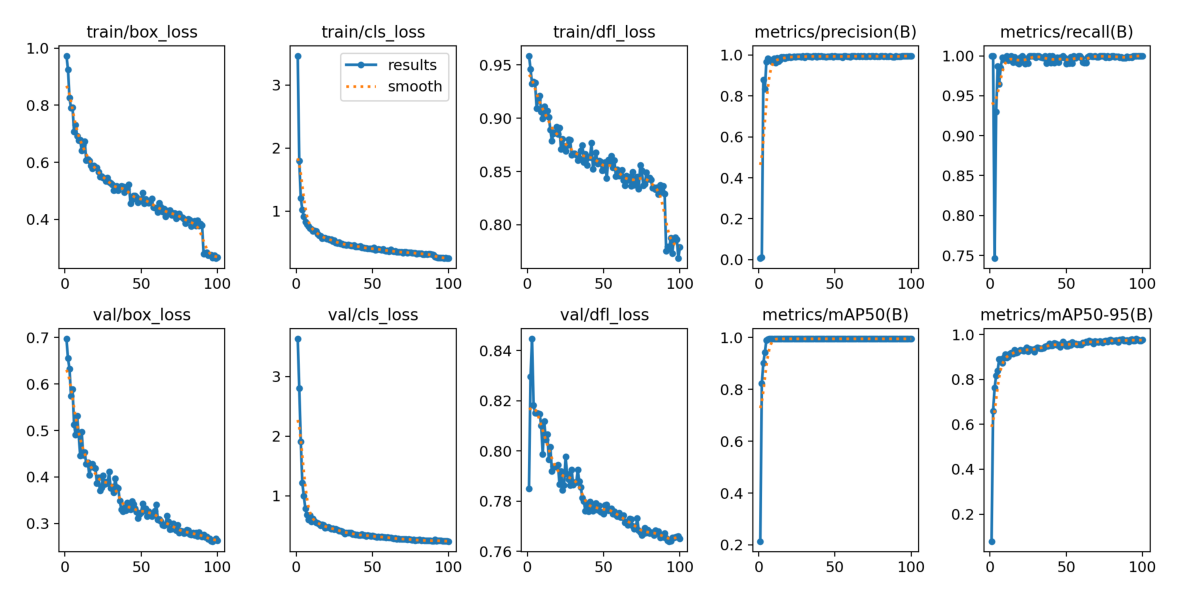

In [22]:
# Find the latest training folder automatically
detect_path = os.path.join(BASE_DIR, 'runs', 'detect')
train_folders = [f for f in os.listdir(detect_path) if f.startswith('train')]
latest_train = sorted(train_folders)[-1]  # gets train5, or whatever is latest
RUNS_PATH = os.path.join(detect_path, latest_train)

print('Using:', RUNS_PATH)

# Display results
metrics = cv2.imread(os.path.join(RUNS_PATH, 'results.png'))
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

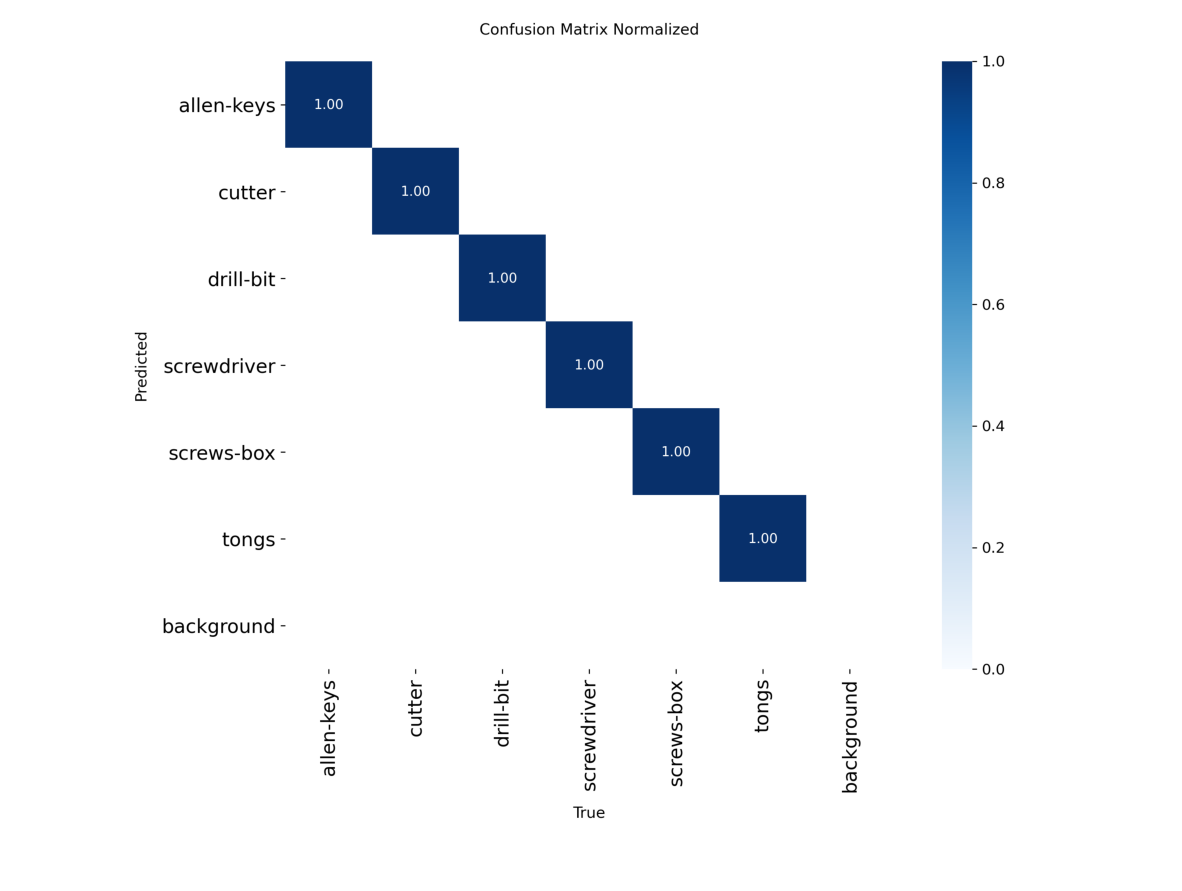

In [ ]:
metrics = cv2.imread(os.path.join(RUNS_PATH, 'confusion_matrix_normalized.png'))
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

## 5. Inference and Visual Testing

Finally, we test the model using the test dataset. We visualize the **Bounding Boxes** and the confidence labels to evaluate the accuracy of localization and classification on images not seen during training.

In [27]:
model = YOLO(os.path.join(RUNS_PATH, 'weights', 'best.pt'))

test_images_path = os.path.join(path_test, 'images')
test_labels_path = os.path.join(path_test, 'labels')

test_images = [
    os.path.join(test_images_path, f)
    for f in os.listdir(test_images_path)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

In [29]:
y_true = []
y_pred = []

for img_path in test_images:

    label_path = os.path.join(
        test_labels_path,
        os.path.basename(img_path).replace(".jpg", ".txt").replace(".png", ".txt")
    )

    # ground truth label
    with open(label_path, "r") as f:
        first_line = f.readline().strip().split(" ")
        true_class = int(first_line[0])
        y_true.append(true_class)

    # YOLO prediction
    result = model(img_path, verbose=False)[0]

    if len(result.boxes) > 0:
        pred_class = int(result.boxes.cls[0].cpu().numpy())
    else:
        pred_class = -1

    y_pred.append(pred_class)

### Confusion Matrix


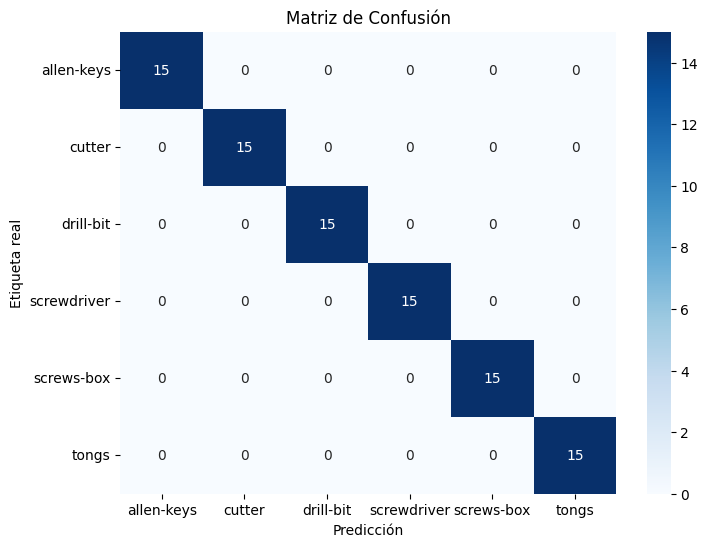

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.names.values(),
            yticklabels=model.names.values())
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.show()

The YOLO model correctly predicts all classes in the test dataset.

### Classification Report

In [31]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(model.names.values()),
    zero_division=0
))

              precision    recall  f1-score   support

  allen-keys       1.00      1.00      1.00        15
      cutter       1.00      1.00      1.00        15
   drill-bit       1.00      1.00      1.00        15
 screwdriver       1.00      1.00      1.00        15
  screws-box       1.00      1.00      1.00        15
       tongs       1.00      1.00      1.00        15

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



### Box MAE (Mean Absolute Error)

In [33]:
from PIL import Image

path_images = os.path.join(path_test, 'images')
path_labels = os.path.join(path_test, 'labels')

model = YOLO(os.path.join(RUNS_PATH, 'weights', 'best.pt'))

mae_xmin, mae_ymin, mae_xmax, mae_ymax = [], [], [], []

for img_name in os.listdir(path_images):
    if not img_name.endswith(".jpg"):
        continue

    img_path = os.path.join(path_images, img_name)

    img = Image.open(img_path)
    width, height = img.size

    result = model(img_path, verbose=False)[0]

    if len(result.boxes) == 0:
        continue

    pred_box = result.boxes.xyxy[0].cpu().numpy()
    xmin_pred, ymin_pred, xmax_pred, ymax_pred = pred_box
    xmin_pred = xmin_pred / width
    ymin_pred = ymin_pred / height
    xmax_pred = xmax_pred / width
    ymax_pred = ymax_pred / height

    label_path = os.path.join(path_labels, img_name.replace(".jpg", ".txt"))
    with open(label_path, "r") as f:
        lines = f.readlines()

    if len(lines) == 0:
        continue

    parts = lines[0].strip().split()
    cls, cx, cy, w, h = map(float, parts)

    xmin_true = cx - w/2
    ymin_true = cy - h/2
    xmax_true = cx + w/2
    ymax_true = cy + h/2

    mae_xmin.append(abs(xmin_true - xmin_pred))
    mae_ymin.append(abs(ymin_true - ymin_pred))
    mae_xmax.append(abs(xmax_true - xmax_pred))
    mae_ymax.append(abs(ymax_true - ymax_pred))

In [34]:
print("MAE xmin:", np.mean(mae_xmin))
print("MAE ymin:", np.mean(mae_ymin))
print("MAE xmax:", np.mean(mae_xmax))
print("MAE ymax:", np.mean(mae_ymax))

MAE xmin: 0.0019486424
MAE ymin: 0.0033985814
MAE xmax: 0.0017808218
MAE ymax: 0.0033312321


Using YOLO, significantly lower MAEs were obtained compared to the other two models.

### Image with Prediction (Classification and Localization)


image 1/1 c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\Data\Test\images\0a0995b5-screws_box1182.jpg: 128x224 1 screws-box, 13.2ms
Speed: 0.6ms preprocess, 13.2ms inference, 0.6ms postprocess per image at shape (1, 3, 128, 224)


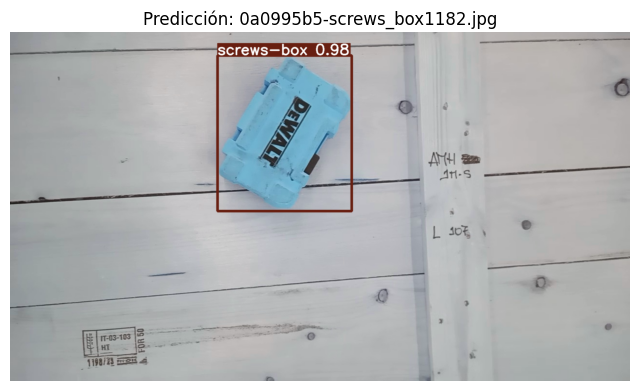

In [35]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

model = YOLO("runs/detect/train/weights/best.pt")

# Select a Test image
test_images_path = path_test + "/images"
img_name = os.listdir(test_images_path)[1]
img_path = os.path.join(test_images_path, img_name)

# Make prediction
results = model(img_path)  # returns an object with all detected boxes

# Extract the first prediction
result = results[0]

# Draw boxes on the image
img_with_boxes = result.plot()  # returns the image with boxes drawn

plt.figure(figsize=(8,8))
plt.imshow(img_with_boxes)
plt.axis('off')
plt.title(f"Predicción: {img_name}")
plt.show()


### Image Comparison: Ground Truth vs YOLO


image 1/1 c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\Data\Test\images\05ea51a1-tongs40.jpg: 128x224 1 tongs, 24.0ms
Speed: 0.7ms preprocess, 24.0ms inference, 0.7ms postprocess per image at shape (1, 3, 128, 224)

image 1/1 c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\Data\Test\images\168f71d4-cutter1280.jpg: 128x224 1 cutter, 12.0ms
Speed: 0.7ms preprocess, 12.0ms inference, 0.5ms postprocess per image at shape (1, 3, 128, 224)

image 1/1 c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\Data\Test\images\2799a4a5-screwdriver148.jpg: 128x224 1 screwdriver, 10.8ms
Speed: 0.5ms preprocess, 10.8ms inference, 0.6ms postprocess per image at shape (1, 3, 128, 224)

image 1/1 c:\Users\jandr\Desktop\Proyectos DL\Clasification&localization_YOLO\data\Data\Test\images\2ca80d63-drill_bit372.jpg: 128x224 1 drill-bit, 11.0ms
Speed: 0.4ms preprocess, 11.0ms inference, 0.5ms postprocess per image at shape (1, 3, 128, 224

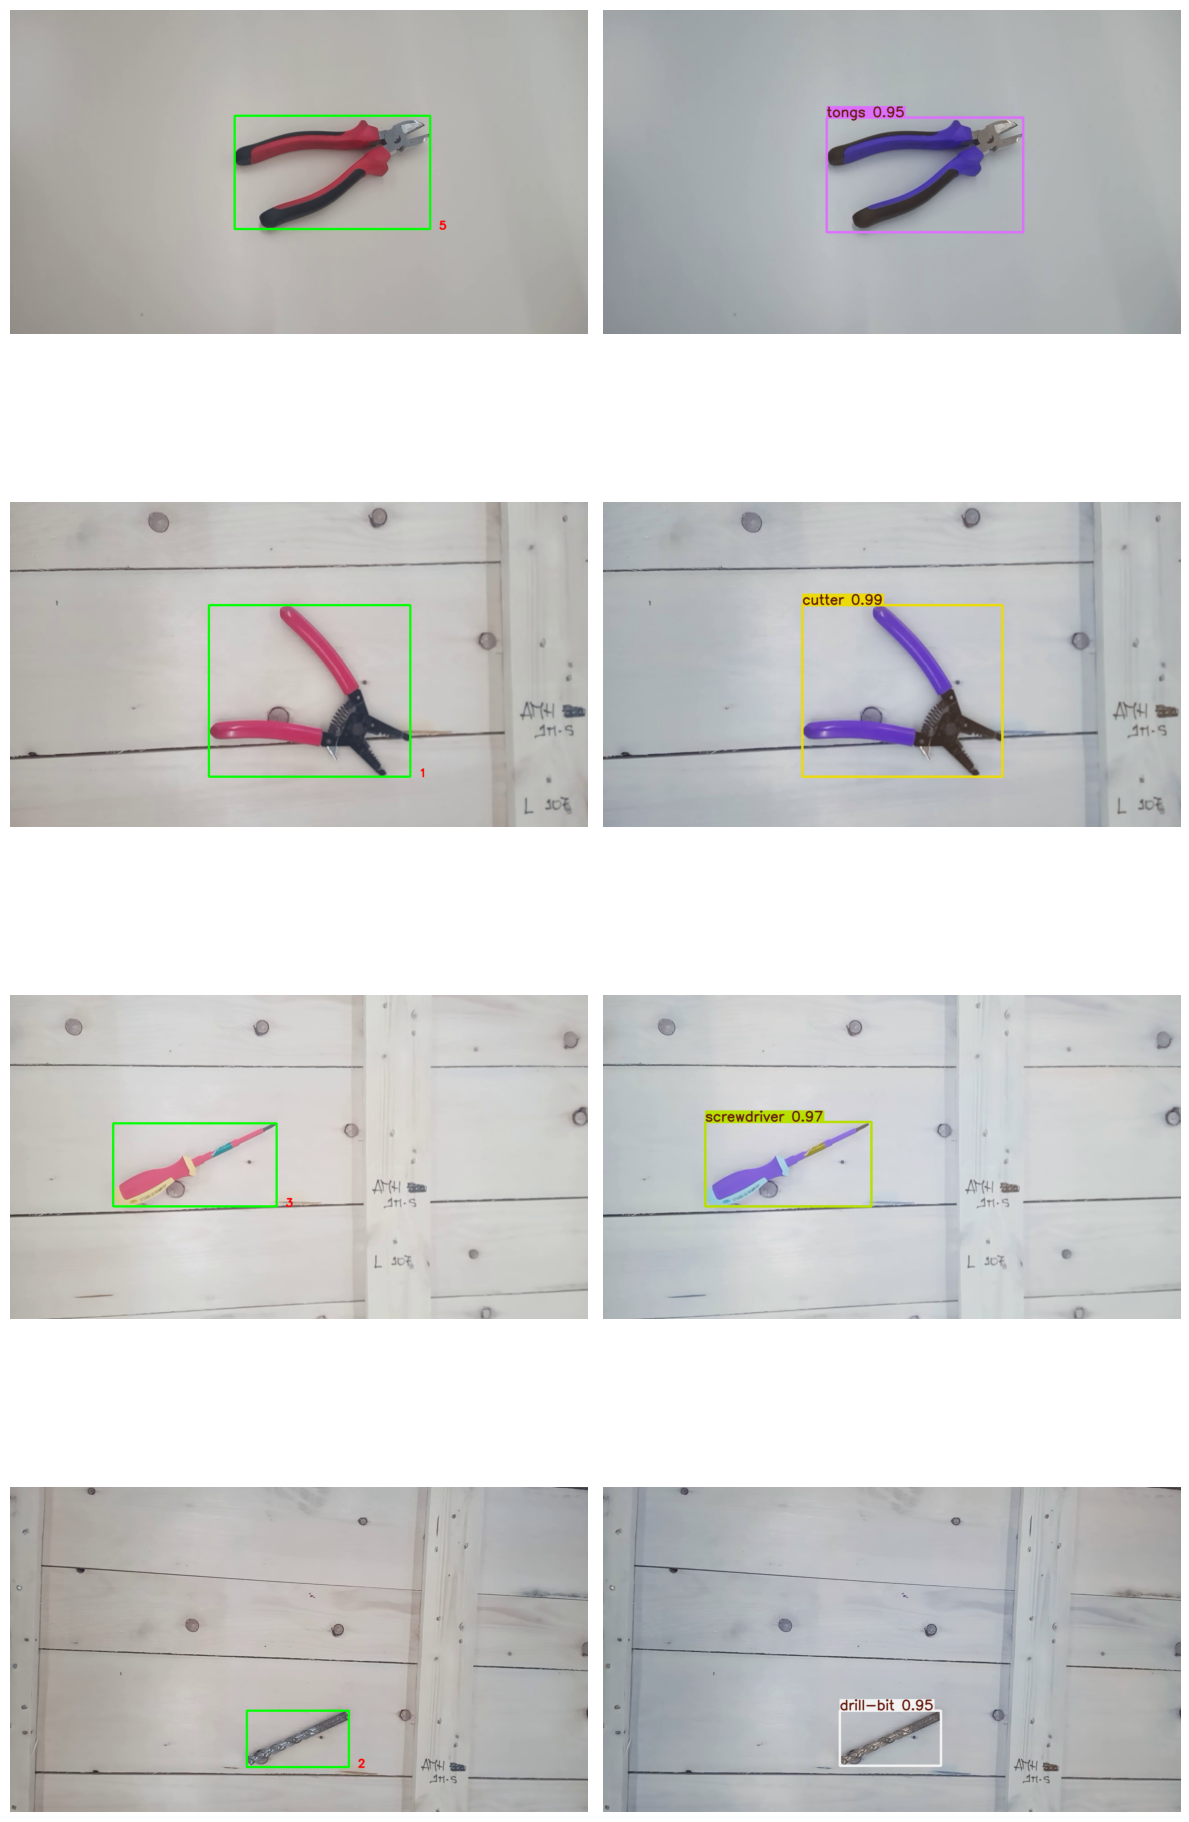

In [36]:
test_images_path = path_test + "/images"
img_names = os.listdir(test_images_path)

# select 4 images
indices = [0, 5, 10, 15]

fig, axes = plt.subplots(4, 2, figsize=(12, 20))

for row, idx in enumerate(indices):

    img_name = img_names[idx]
    img_path = os.path.join(test_images_path, img_name)

    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    img_pred = img_original.copy()
    img_true = img_original.copy()

    height, width, _ = img_original.shape

    # Prediction
    results = model(img_path)
    result = results[0]

    img_pred_with_boxes = result.plot()

    # Ground truth label box
    label_path = path_test + "/labels/" + img_name.replace(".jpg", ".txt")

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, w, h = map(float, line.strip().split())

        xmin = int((cx - w/2) * width)
        ymin = int((cy - h/2) * height)
        xmax = int((cx + w/2) * width)
        ymax = int((cy + h/2) * height)

        cv2.rectangle(img_true, (xmin, ymin), (xmax, ymax), (0,255,0), 3)

        # Actual class
        class_id = int(cls)

        cv2.putText(
            img_true,
            str(class_id),
             (xmax + 20, ymax),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
             (255, 0, 0),
            2,
            cv2.LINE_AA
            )

    # Plot
    axes[row, 0].imshow(img_true)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img_pred_with_boxes)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()
